In [ ]:
import pandas as pd
import numpy as np

# Tạo DataFrame với dữ liệu thô
df = pd.read_csv('/content/insurance.csv')
print("DataFrame gốc:")
display (df)

# Kiểm tra dữ liệu thiếu trong cột
print(f"Du lieu thieu theo cot: {df.isna().any()}")
# Kết luận: không có dữ liệu thiếu

# Trong dữ liệu y tế, các chỉ số giống nhau từ các đối tượng khác nhau hoàn toàn có thể xảy ra, ta không cần xoá bỏ các dữ liệu trùng lặp
print(f"So luong du lieu trung lap: {df.duplicated().sum()}")

# Tạo bản copy của DataFrame gốc để làm sạch
df_refined = df.copy()

# Xử lý các chuỗi ký tự không đồng nhất bằng cách chuẩn hóa tất cả về chữ thường và loại bỏ khoảng trắng thừa
df_refined['sex'] = df_refined['sex'].str.lower().str.strip()
df_refined['smoker'] = df_refined['smoker'].str.lower().str.strip()
df_refined['region'] = df_refined['region'].str.lower().str.strip()

print(f"Gia tri khong trung lap trong cot 'sex': {df_refined['sex'].unique()}")
print(f"Gia tri khong trung lap trong cot 'smoker': {df_refined['smoker'].unique()}")
print(f"Gia tri khong trung lap trong cot 'region': {df_refined['region'].unique()}")



# Xử lí dữ liệu phân loại bằng One-Hot Encoding cho các cột có dữ liệu nominal
df_encoded = pd.get_dummies(df_refined, columns=['sex' , 'smoker' , 'region'], dummy_na= False )

# Sử dụng RobustScaler để xử lí outliers
from sklearn.preprocessing import RobustScaler
import pandas as pd

scaler = RobustScaler()

# Scale các cột số có outliers là 'bmi' và 'charges'
columns_to_scale = ['bmi', 'charges']
df_encoded[columns_to_scale] = scaler.fit_transform(df_encoded[columns_to_scale])

print("DataFrame được làm sạch:")
display(df_encoded)


DataFrame gốc:


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


Du lieu thieu theo cot: age         False
sex         False
bmi         False
children    False
smoker      False
region      False
charges     False
dtype: bool
So luong du lieu trung lap: 1
Gia tri khong trung lap trong cot 'sex': ['female' 'male']
Gia tri khong trung lap trong cot 'smoker': ['yes' 'no']
Gia tri khong trung lap trong cot 'region': ['southwest' 'southeast' 'northwest' 'northeast']
DataFrame được làm sạch:


,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,-0.297708,0,0.630515,True,False,False,True,False,False,False,True
1,18,0.401310,1,-0.643422,False,True,True,False,False,False,True,False
2,28,0.309616,3,-0.414515,False,True,True,False,False,False,True,False
3,33,-0.916344,0,1.059062,False,True,True,False,False,True,False,False
4,32,-0.181006,0,-0.463475,False,True,True,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,0.067877,3,0.102399,False,True,True,False,False,True,False,False
1334,18,0.181006,0,-0.603049,True,False,True,False,True,False,False,False
1335,18,0.768086,0,-0.651466,True,False,True,False,False,False,True,False
1336,21,-0.547782,0,-0.619691,True,False,True,False,False,False,False,True


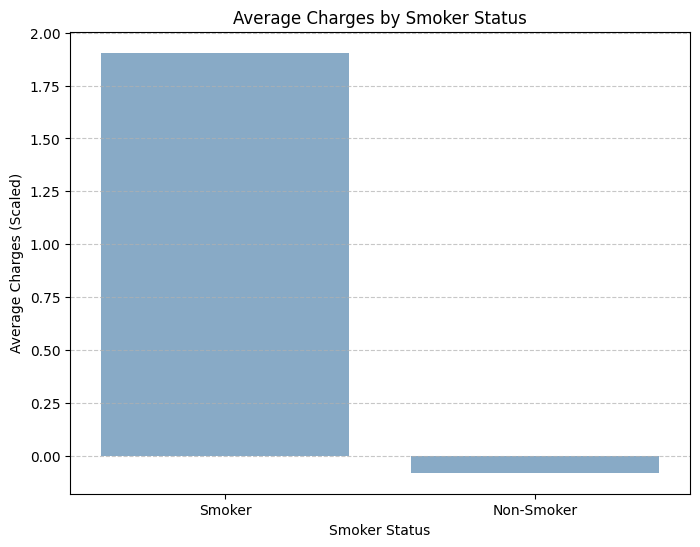

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Tính chi phí y tế trung bình cho người hút thuốc và không hút thuốc
avg_charges_smoker = df_encoded[df_encoded['smoker_yes'] == True]['charges'].mean()
avg_charges_non_smoker = df_encoded[df_encoded['smoker_no'] == True]['charges'].mean()

# Tạo một DataFrame mới
avg_charges_by_smoker = pd.DataFrame({
    'smoker_status': ['Smoker', 'Non-Smoker'],
    'charges': [avg_charges_smoker, avg_charges_non_smoker]
})

# Tạo Bar Chart
plt.figure(figsize=(8, 6))
sns.barplot(x='smoker_status', y='charges', data=avg_charges_by_smoker, color="#7EABD0")
plt.title('Average Charges by Smoker Status')
plt.xlabel('Smoker Status')
plt.ylabel('Average Charges (Scaled)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

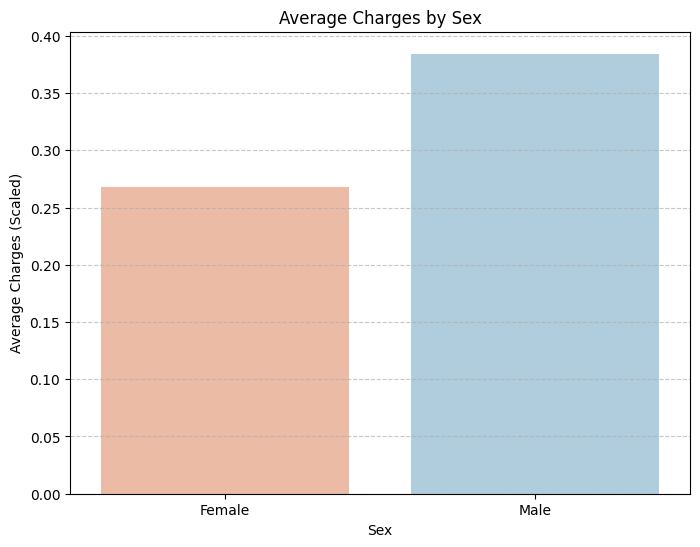

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# CTính chi phí y tế trung bình cho nam và nữ
avg_charges_female = df_encoded[df_encoded['sex_female'] == True]['charges'].mean()
avg_charges_male = df_encoded[df_encoded['sex_male'] == True]['charges'].mean()

# Tạo DataFrame mới
avg_charges_by_sex = pd.DataFrame({
    'sex_status': ['Female', 'Male'],
    'charges': [avg_charges_female, avg_charges_male]
})

# Tạo Bar Chart
plt.figure(figsize=(8, 6))
sns.barplot(x='sex_status', y='charges', data=avg_charges_by_sex, hue='sex_status', palette='RdBu', legend=False)
plt.title('Average Charges by Sex')
plt.xlabel('Sex')
plt.ylabel('Average Charges (Scaled)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

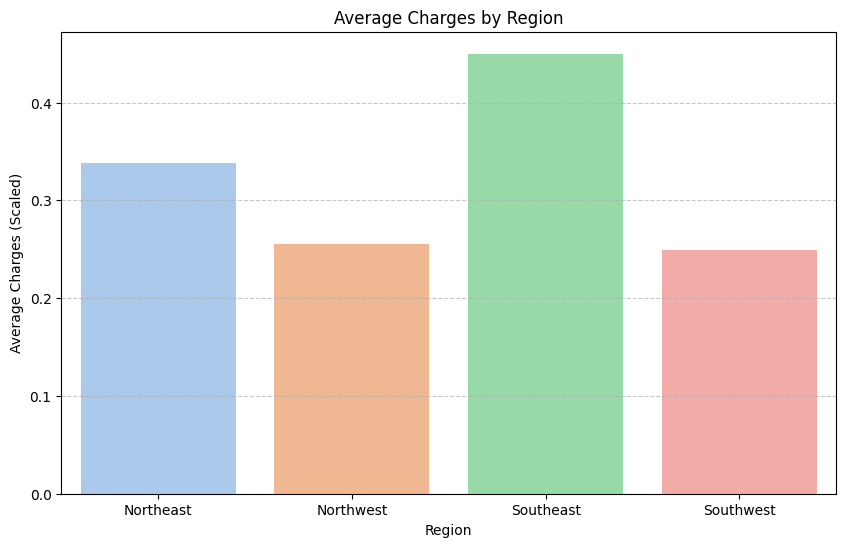

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Tính chi phí y tế trung bình cho từng vùng
avg_charges_northeast = df_encoded[df_encoded['region_northeast'] == True]['charges'].mean()
avg_charges_northwest = df_encoded[df_encoded['region_northwest'] == True]['charges'].mean()
avg_charges_southeast = df_encoded[df_encoded['region_southeast'] == True]['charges'].mean()
avg_charges_southwest = df_encoded[df_encoded['region_southwest'] == True]['charges'].mean()

# Tạo DataFrame mới
avg_charges_by_region = pd.DataFrame({
    'region_status': ['Northeast', 'Northwest', 'Southeast', 'Southwest'],
    'charges': [avg_charges_northeast, avg_charges_northwest, avg_charges_southeast, avg_charges_southwest]
})

# Tạo Bar Chart
plt.figure(figsize=(10, 6))
sns.barplot(x='region_status', y='charges', data=avg_charges_by_region, hue='region_status', palette='pastel', legend=False)
plt.title('Average Charges by Region')
plt.xlabel('Region')
plt.ylabel('Average Charges (Scaled)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

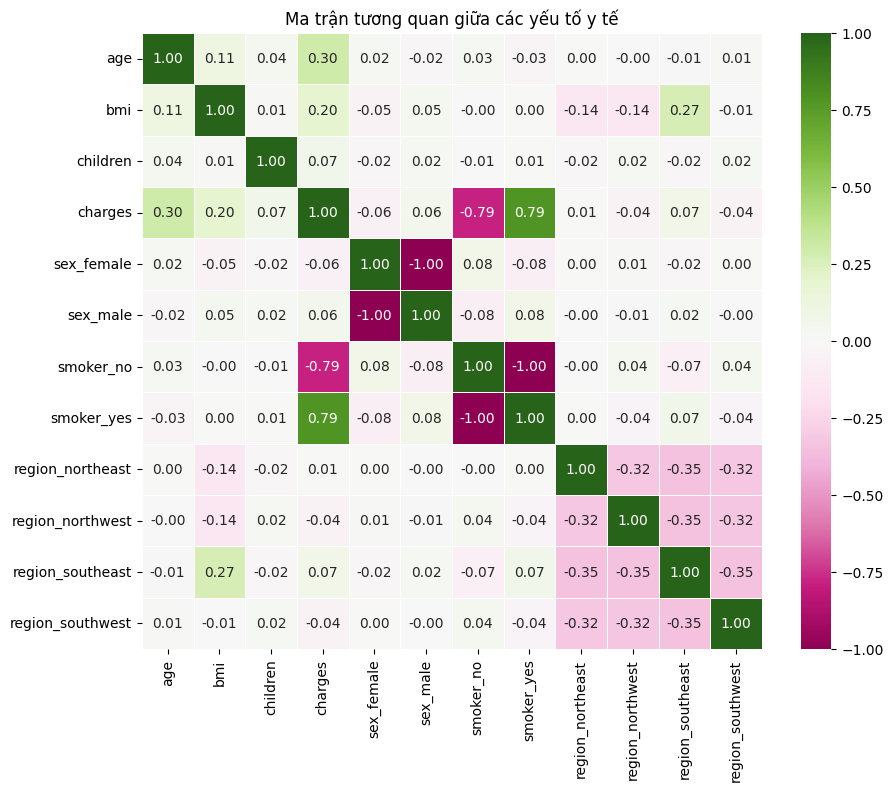

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập kích thước
plt.figure(figsize=(10, 8))

# Tạo heatmap
sns.heatmap(df_encoded.corr(), annot=True, cmap='PiYG', fmt=".2f", linewidths=0.5)

plt.title('Ma trận tương quan giữa các yếu tố y tế')
plt.show()

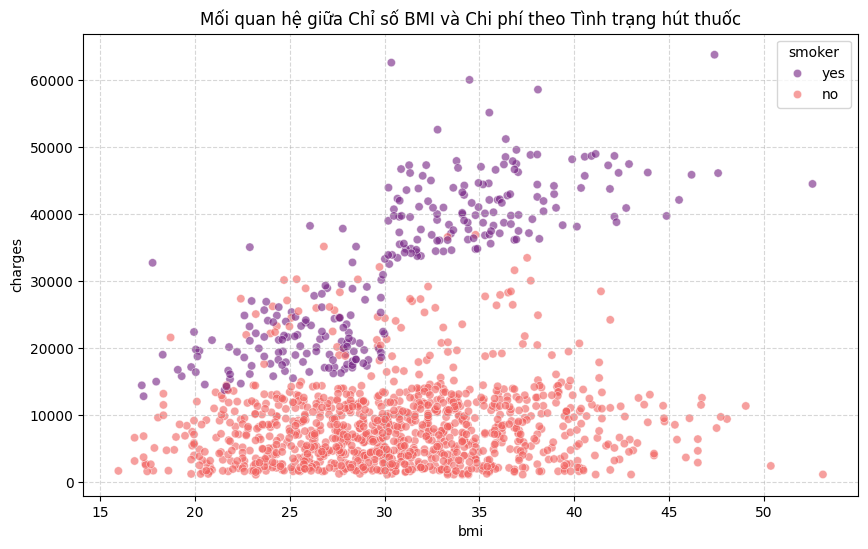

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập kích thước
plt.figure(figsize=(10, 6))

sns.scatterplot(data=df, x='bmi', y='charges', hue='smoker', alpha=0.6, palette='magma')

plt.title('Mối quan hệ giữa Chỉ số BMI và Chi phí theo Tình trạng hút thuốc')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

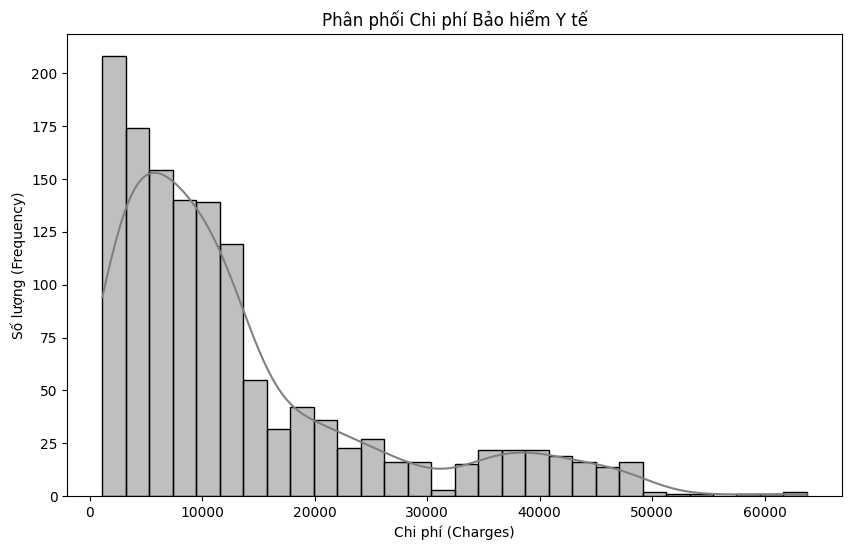

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 6))

# Sử dụng bins=30 để chia nhỏ dữ liệu hơn, giúp thấy rõ các khoảng trống
sns.histplot(df['charges'], kde=True, bins=30, color='grey')

plt.title('Phân phối Chi phí Bảo hiểm Y tế')
plt.xlabel('Chi phí (Charges)')
plt.ylabel('Số lượng (Frequency)')
plt.show()